# Portfolio Optimization as a Regression Problem

Companion to the **Portfolio Optimization Application** section of the lecture. Britten-Jones
(1999) shows that Markowitz weights can be recovered from a regression: regress a column of
ones on the excess returns of $N$ assets, with no intercept,

$$\mathbf{1}_T = \mathbf{R}^e\boldsymbol{\theta} + \boldsymbol{\eta},$$

then rescale the coefficients so they sum to one.

Portfolio weights are then *estimates*, and
the lecture's penalties apply to them directly: ridge gives the Tikhonov portfolio, lasso the
sparse portfolio.

**After this notebook you should be able to:**

1. obtain Markowitz weights from a regression and check them against the textbook rule;
2. estimate Tikhonov portfolio and sparse portfolio weights;
3. tune a penalty on validation months and evaluate out of sample against $1/N$.

## 1. Setup and data

`returns.csv` holds monthly returns for 1,779 US stocks, 2007-12 to 2018-12, with no gaps. A
balanced dataset with survivorship-bias.

`rf.csv` holds FRED's `TB4WK`, quoted as an **annualized percentage** and stamped at the first of the month. It is divided by 100 *and* by 12 to become a monthly decimal.

`fit_intercept=False` throughout: an intercept would fit the column of ones without using the
assets, and the coefficients would stop being portfolio weights.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso

pd.set_option("display.precision", 4)
plt.rcParams["figure.figsize"] = (9, 4)
plt.rcParams["axes.grid"] = True

SEED = 710
MONTHS_PER_YEAR = 12

TRAIN_END = pd.Period("2013-12", freq="M")   # last month used to estimate weights
VALID_END = pd.Period("2016-06", freq="M")   # last month used to choose the penalty

N_SUBSET = 40        # small universe for Section 2 only, where T > N
WINDOW = 60          # rolling estimation window, in months
COST_BPS = 25        # trading cost, charged only when reporting out-of-sample results

BLUE, GREEN, GOLD, RED = "#003865", "#64A70B", "#F2A900", "#DA291C"

In [2]:
raw_returns = pd.read_csv(Path("returns.csv"))
raw_returns["date"] = pd.to_datetime(raw_returns["date"], format="%Y%m%d")
raw_returns = raw_returns.set_index("date").sort_index()
raw_returns.index = raw_returns.index.to_period("M")   # month-end stamp -> month
raw_returns.columns.name = "ticker"

# Annualized percent -> monthly decimal, stamped by month rather than by day
risk_free = pd.read_csv(Path("rf.csv"), parse_dates=["DATE"]).set_index("DATE")["TB4WK"]
risk_free = risk_free / 100 / MONTHS_PER_YEAR
risk_free.index = risk_free.index.to_period("M")

# Excess returns: the left-hand side of Britten-Jones is a column of ones, so returns
# must already be in excess of the risk-free rate
months = raw_returns.index.intersection(risk_free.index)
excess_returns = raw_returns.loc[months].sub(risk_free.loc[months], axis=0)

T, N = excess_returns.shape
equal_weight = pd.Series(np.full(N, 1 / N), index=excess_returns.columns)

print(f"Excess returns : {T} months x {N} stocks, {excess_returns.index.min()} to "
      f"{excess_returns.index.max()}")
print(f"Missing entries: {excess_returns.isna().sum().sum()}")
print(f"T / N          : {WINDOW / N:.3f} on a {WINDOW}-month estimation window")
print(f"Equal weight   : {100 / N:.4f}% per name")
excess_returns.iloc[:3, :6]

Excess returns : 133 months x 1779 stocks, 2007-12 to 2018-12
Missing entries: 0
T / N          : 0.034 on a 60-month estimation window
Equal weight   : 0.0562% per name


ticker,A,AAME,AAON,AAP,AAPL,AAWW
2007-12,-0.0311,-0.2023,0.0476,0.0558,0.0847,0.0275
2008-01,-0.0806,0.1335,-0.1042,-0.0604,-0.3189,-0.0812
2008-02,-0.0978,-0.0270,-0.0743,-0.0645,-0.0782,0.0114


## 2. Markowitz weights are regression coefficients

The textbook Markowitz portfolio
$\widehat\Sigma^{-1}\widehat{\boldsymbol\mu}$ needs an invertible covariance matrix, which
1,779 assets and 60 months of history cannot supply. So for this section only I use a random
draw of 40 tickers, giving $T/N = 1.5$. Sections 3 onwards return to all 1,779.

Compute the weights both ways, rescale both to sum to one, and compare.

Weights are estimated on a **rolling 60-month window** throughout. Five years is a common
lookback, and as the lecture notes, older data may no longer be representative of the market
being traded.

In [3]:
# Three blocks: fit on train, choose the penalty on validation, touch test only once
train = excess_returns.loc[:TRAIN_END]
valid = excess_returns.loc[(excess_returns.index > TRAIN_END) & (excess_returns.index <= VALID_END)]
test = excess_returns.loc[excess_returns.index > VALID_END]

# The most recent window inside the training block, used for Sections 2 and 3
estimation = train.iloc[-WINDOW:]

# Random draw, so nothing is selected on the strength of its returns
subset_tickers = sorted(np.random.default_rng(SEED).choice(excess_returns.columns,
                                                           size=N_SUBSET, replace=False))
subset = estimation[subset_tickers]

for name, block in [("train", train), ("validation", valid), ("test", test)]:
    print(f"{name:<11}: {block.index.min()} to {block.index.max()}  {len(block):>3} months")
print(f"\nEstimation window: {estimation.index.min()} to {estimation.index.max()} "
      f"({WINDOW} months)")
print(f"Section 2 subset : {N_SUBSET} random tickers, T/N = {WINDOW / N_SUBSET:.1f}")


def portfolio_weights(returns, penalty="none", alpha=0.0, long_only=False):
    """Britten-Jones weights: regress ones on excess returns, no intercept, rescale to sum to 1."""
    # long_only=True imposes the no-short-sales constraint, theta >= 0
    if penalty == "none":
        model = LinearRegression(fit_intercept=False, positive=long_only)
    elif penalty == "ridge":
        model = Ridge(alpha=alpha, fit_intercept=False, positive=long_only)
    elif penalty == "lasso":
        model = Lasso(alpha=alpha, fit_intercept=False, positive=long_only,
                      max_iter=200_000, random_state=SEED)
    else:
        raise ValueError("penalty must be 'none', 'ridge' or 'lasso'")

    # Assets differ in volatility several times over, and a penalty applied to raw
    # coefficients is not scale-free: it shrinks low-volatility names hardest. So scale
    # each asset to unit volatility, penalize, then undo the scaling. OLS is unaffected.
    scale = returns.std(ddof=0).to_numpy()

    # The regressand is a column of ones -- this is the Britten-Jones regression
    model.fit(returns.to_numpy() / scale, np.ones(len(returns)))

    theta = model.coef_ / scale
    # A penalty large enough to zero every coefficient leaves nothing to rescale
    if np.abs(theta.sum()) < 1e-12:
        raise ValueError(f"{penalty} penalty of {alpha:.3g} left no non-zero coefficients")

    # Rescaling to sum to one is what turns coefficients into portfolio weights
    return pd.Series(theta / theta.sum(), index=returns.columns, name="weight")

train      : 2007-12 to 2013-12   73 months
validation : 2014-01 to 2016-06   30 months
test       : 2016-07 to 2018-12   30 months

Estimation window: 2009-01 to 2013-12 (60 months)
Section 2 subset : 40 random tickers, T/N = 1.5


In [4]:
# Route 1: the Britten-Jones regression of ones on excess returns
w_regression = portfolio_weights(subset, "none")

# Route 2: the textbook rule, covariance matrix inverted onto the average returns
theta_markowitz = np.linalg.solve(subset.cov().to_numpy(), subset.mean().to_numpy())
w_markowitz = pd.Series(theta_markowitz / theta_markowitz.sum(), index=subset.columns)

# If Britten-Jones holds, the two weight vectors agree to numerical precision
print(f"Largest gap between the two routes: {(w_regression - w_markowitz).abs().max():.2e}\n")
print(f"Gross exposure  sum|w| : {w_regression.abs().sum():.1f}   (1.0 = no leverage)")
print(f"Names held short       : {100 * (w_regression < 0).mean():.0f}%")
print(f"Largest long / short   : {w_regression.max():+.1%} / {w_regression.min():+.1%}")
print(f"Equal weight, for scale: {1 / N_SUBSET:+.2%}")

Largest gap between the two routes: 1.43e-14

Gross exposure  sum|w| : 7.2   (1.0 = no leverage)
Names held short       : 45%
Largest long / short   : +67.0% / -64.6%
Equal weight, for scale: +2.50%


Let's look at the 'optimal portfolio'.

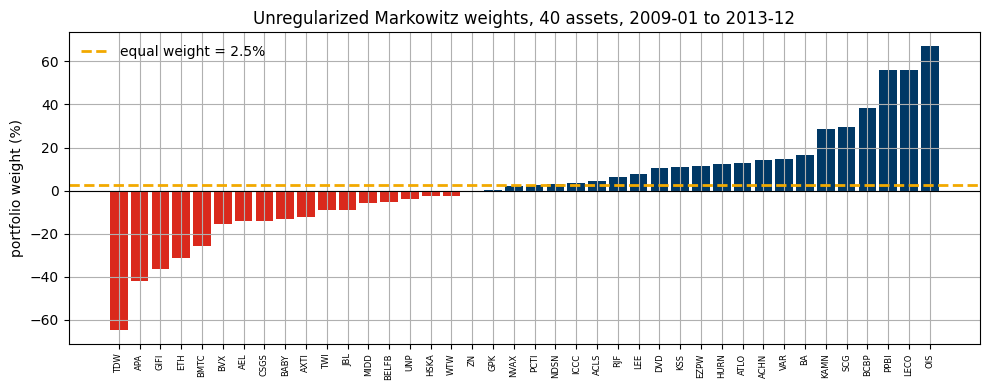

In [5]:
ordered = w_regression.sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(N_SUBSET), 100 * ordered.to_numpy(), width=0.85,
       color=[RED if w < 0 else BLUE for w in ordered])   # short positions in red
ax.axhline(100 / N_SUBSET, color=GOLD, lw=2, ls="--",
           label=f"equal weight = {100 / N_SUBSET:.1f}%")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(range(N_SUBSET))
ax.set_xticklabels(ordered.index, rotation=90, fontsize=6)
ax.set_ylabel("portfolio weight (%)")
ax.set_title(f"Unregularized Markowitz weights, {N_SUBSET} assets, "
             f"{subset.index.min()} to {subset.index.max()}")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 3. Penalizing the weights

Back to all 1,779 assets. Ridge makes large positions expensive before the weights are
normalized. The $\ell_1$ penalty instead sets weights *exactly* to zero, shortening the
holdings list --- sparse Markowitz in the sense of Brodie et al. (2009).

Both penalties act on coefficients, so the regressors have to be on a common scale first.
Volatilities here range from roughly 20% to 80% a year, and an unscaled penalty would shrink
the quietest names hardest --- selecting on volatility rather than on signal. Each asset is
therefore scaled to unit volatility inside `portfolio_weights` before the penalty is applied,
exactly as the topic shares are standardized in `Volatility_and_Business_News.ipynb`.

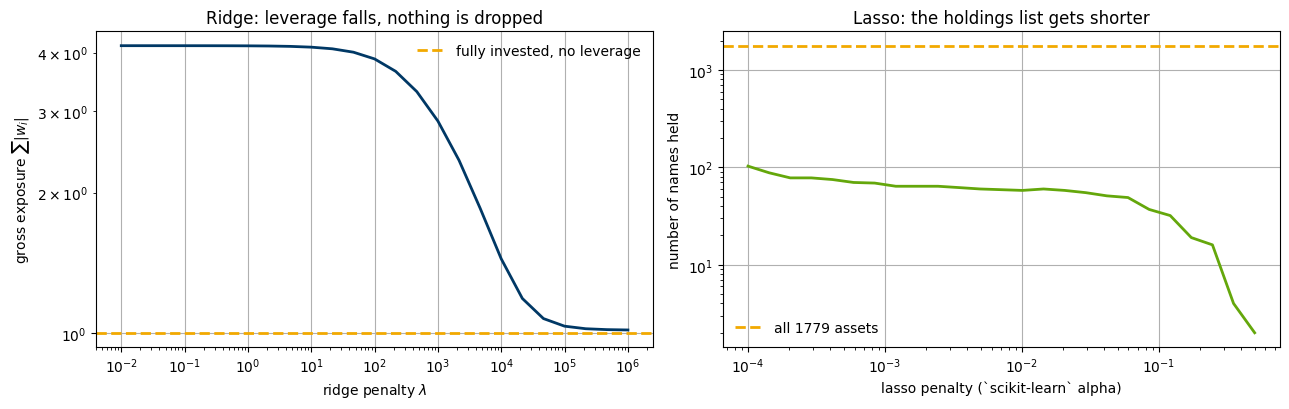

Ridge: gross exposure 4.1 -> 1.01, all 1779 names always held
Lasso: names held 103 -> 2 out of 1779


In [6]:
ridge_lambdas = np.logspace(-2, 6, 25)
lasso_alphas = np.logspace(-4, -0.3, 25)   # beyond this the lasso zeroes every coefficient

# Gross exposure measures leverage; a count of non-zero weights measures sparsity
ridge_gross = [portfolio_weights(estimation, "ridge", lam).abs().sum() for lam in ridge_lambdas]
lasso_names = [(portfolio_weights(estimation, "lasso", a).abs() > 1e-8).sum() for a in lasso_alphas]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].plot(ridge_lambdas, ridge_gross, color=BLUE, lw=2)
axes[0].axhline(1.0, color=GOLD, lw=2, ls="--", label="fully invested, no leverage")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"ridge penalty $\lambda$")
axes[0].set_ylabel(r"gross exposure $\sum|w_i|$")
axes[0].set_title("Ridge: leverage falls, nothing is dropped")
axes[0].legend(frameon=False)

axes[1].plot(lasso_alphas, lasso_names, color=GREEN, lw=2)
axes[1].axhline(N, color=GOLD, lw=2, ls="--", label=f"all {N} assets")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("lasso penalty (`scikit-learn` alpha)")
axes[1].set_ylabel("number of names held")
axes[1].set_title("Lasso: the holdings list gets shorter")
axes[1].legend(frameon=False)

plt.tight_layout()
plt.show()

print(f"Ridge: gross exposure {ridge_gross[0]:.1f} -> {ridge_gross[-1]:.2f}, "
      f"all {N} names always held")
print(f"Lasso: names held {lasso_names[0]} -> {lasso_names[-1]} out of {N}")

## 4. Choosing the penalty on validation months

$\lambda$ is chosen on months after the estimation months and before the test months. Forecast
accuracy is the wrong criterion (as the dependent variable is a column of ones) so we choose the
penalty that **maximizes the annualized Sharpe ratio** an investor would have earned on the
validation months. 

Weights are re-estimated every month from the preceding 60 months, so the
information set is always the one available at the decision date.


Three estimators: ridge, lasso, and lasso with no short sales ($\theta \ge 0$). 

In [7]:
def run_strategy(returns, dates, penalty, alpha=0.0, long_only=False):
    """Rolling window: estimate on the WINDOW months before `date`, hold through it."""
    records, previous = [], None

    for date in dates:
        history = returns.loc[returns.index < date].iloc[-WINDOW:]   # no look-ahead
        weights = portfolio_weights(history, penalty, alpha, long_only)

        # Turnover is what a cost is charged on: how much of the book is traded
        turnover = 0.0 if previous is None else (weights - previous).abs().sum()
        records.append({
            "date": date,
            # Weights set before the month, applied to the returns realized during it
            "gross": returns.loc[date].to_numpy() @ weights.to_numpy(),
            "turnover": turnover,
            "names_held": int((weights.abs() > 1e-8).sum()),
            "gross_exposure": weights.abs().sum(),
        })
        previous = weights

    return pd.DataFrame(records).set_index("date")


def performance(returns, label):
    """Annualized mean, volatility, Sharpe ratio and maximum drawdown."""
    r = np.asarray(returns, dtype=float)
    mean = r.mean() * MONTHS_PER_YEAR
    volatility = r.std(ddof=1) * np.sqrt(MONTHS_PER_YEAR)
    wealth = np.cumprod(1 + r)

    # Drawdown: loss from the running peak of the wealth path
    return pd.Series({
        "annualized mean": mean,
        "annualized vol": volatility,
        "Sharpe ratio": mean / volatility,
        "max drawdown": (wealth / np.maximum.accumulate(wealth) - 1).min(),
    }, name=label)

Validation: 2014-01 to 2016-06 (30 months), Sharpe ratio gross of costs

equal weight (1/N)     : +0.373   (estimates nothing, trades nothing)
ridge                  : +1.058   at 3.16e+03  (grid point 10 of 15)
lasso                  : +1.810   at 0.299     (grid point 12 of 13)
lasso, no short sales  : +1.795   at 0.299     (grid point 12 of 13)


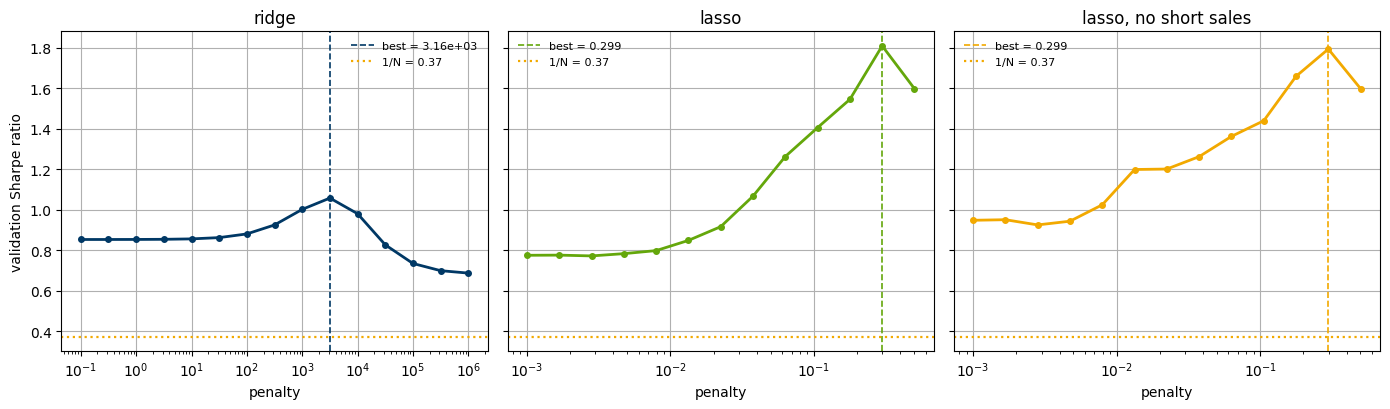

In [8]:
# label: (penalty grid, sklearn estimator, no-short-sales constraint, plot colour)
estimators = {
    "ridge": (np.logspace(-1, 6, 15), "ridge", False, BLUE),
    "lasso": (np.logspace(-3, -0.3, 13), "lasso", False, GREEN),
    "lasso, no short sales": (np.logspace(-3, -0.3, 13), "lasso", True, GOLD),
}

tuned, scores = {}, {}
for label, (grid, penalty, long_only, _) in estimators.items():
    # Backtest the validation months once per candidate penalty. Scoring uses "gross"
    # returns: trading costs are deliberately excluded from the tuning criterion.
    scores[label] = np.array([
        performance(run_strategy(excess_returns, valid.index, penalty, alpha, long_only)["gross"],
                    alpha)["Sharpe ratio"] for alpha in grid
    ])
    tuned[label] = grid[scores[label].argmax()]        # the max-Sharpe penalty

# The benchmark to beat: 1/N estimates nothing and so has no penalty to tune
ew_score = performance(valid @ equal_weight, "1/N")["Sharpe ratio"]

print(f"Validation: {valid.index.min()} to {valid.index.max()} ({len(valid)} months), "
      f"Sharpe ratio gross of costs\n")
print(f"{'equal weight (1/N)':<23}: {ew_score:+.3f}   (estimates nothing, trades nothing)")
for label, (grid, _, _, _) in estimators.items():
    position = int(scores[label].argmax()) + 1
    print(f"{label:<23}: {scores[label].max():+.3f}   at {tuned[label]:<9.3g} "
          f"(grid point {position} of {len(grid)})")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, (label, (grid, _, _, colour)) in zip(axes, estimators.items()):
    ax.plot(grid, scores[label], color=colour, lw=2, marker="o", ms=4)
    ax.axvline(tuned[label], color=colour, lw=1.2, ls="--", label=f"best = {tuned[label]:.3g}")
    ax.axhline(ew_score, color=GOLD, lw=1.6, ls=":", label=f"1/N = {ew_score:.2f}")
    ax.set_xscale("log")
    ax.set_xlabel("penalty")
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=8)

axes[0].set_ylabel("validation Sharpe ratio")
plt.tight_layout()
plt.show()

## 5. Out-of-sample test

The penalties are fixed, so the test months can be used once. Trading costs enter here: these
portfolios trade, and $1/N$ never does.

In [9]:
rows, return_paths = [], []
for label, (grid, penalty, long_only, _) in estimators.items():
    # tuned[label] is fixed by Section 4, so the test months are used exactly once
    backtest = run_strategy(excess_returns, test.index, penalty, tuned[label], long_only)

    summary = performance(backtest["gross"], f"{label} ({tuned[label]:.3g})")
    # Charge a proportional cost on the amount traded each month
    summary[f"Sharpe, {COST_BPS}bp"] = performance(
        backtest["gross"] - (COST_BPS / 1e4) * backtest["turnover"], label)["Sharpe ratio"]
    summary["turnover"] = backtest["turnover"].iloc[1:].mean()
    summary["gross exposure"] = backtest["gross_exposure"].mean()
    summary["names held"] = backtest["names_held"].mean()

    rows.append(summary)
    return_paths.append((f"{label} ({tuned[label]:.3g})", backtest["gross"]))

# 1/N estimates nothing, so it has no penalty to tune and nothing to trade
summary = performance(test @ equal_weight, "equal weight (1/N)")
summary[f"Sharpe, {COST_BPS}bp"] = summary["Sharpe ratio"]
summary["turnover"], summary["gross exposure"], summary["names held"] = 0.0, 1.0, N
rows.append(summary)
return_paths.append(("equal weight (1/N)", test @ equal_weight))

print(f"Test: {test.index.min()} to {test.index.max()} ({len(test)} months), {N} assets, "
      f"rolling {WINDOW}-month window\n")
pd.DataFrame(rows).round(3)

Test: 2016-07 to 2018-12 (30 months), 1779 assets, rolling 60-month window



,annualized mean,annualized vol,Sharpe ratio,max drawdown,"Sharpe, 25bp",turnover,gross exposure,names held
ridge (3.16e+03),0.109,0.096,1.137,-0.102,1.042,0.312,1.898,1779.000
lasso (0.299),0.108,0.123,0.879,-0.114,0.767,0.468,1.020,10.433
"lasso, no short sales (0.299)",0.086,0.133,0.648,-0.165,0.553,0.440,1.000,10.133
equal weight (1/N),0.082,0.145,0.563,-0.209,0.563,0.000,1.000,1779.000


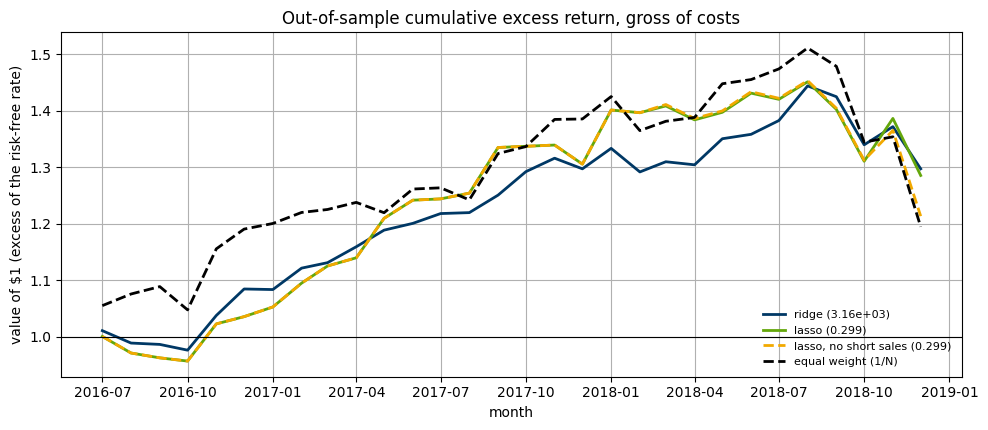

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.4))
for (label, path), colour, style in zip(return_paths, [BLUE, GREEN, GOLD, "black"],
                                       ["-", "-", "--", "--"]):
    ax.plot(path.index.to_timestamp(), (1 + path).cumprod(), lw=2, color=colour, ls=style,
            label=label)
ax.axhline(1.0, color="black", lw=0.8)
ax.set_ylabel("value of $1 (excess of the risk-free rate)")
ax.set_xlabel("month")
ax.set_title("Out-of-sample cumulative excess return, gross of costs")
ax.legend(frameon=False, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

All three penalized portfolios beat $1/N$ before costs, and every one of them does it the same
way: not by earning more, but by giving up much less volatility. Each has a shallower drawdown
and a milder worst month than equal weighting.

**Ridge** is the best of the four on every measure that matters here --- the highest Sharpe ratio
before and after costs, the shallowest drawdown, and the mildest worst month. It holds all 1,779
names at a gross exposure just under 2, which is the Tikhonov portfolio doing exactly what the
lecture says it should: spreading exposure thinly rather than dropping anything.

**Both lassos** hold about ten names out of 1,779. That is a remarkable amount of compression,
and it survives out of sample --- but it costs something. Concentration raises volatility, and
after 25bp of trading costs the long-only version slips just below $1/N$. Sparsity is a
constraint you impose because you want a short holdings list, not because it improves the
portfolio for free.

Note also what happened to the gap between the two lasso rows once the penalty was put on a
common scale. Section 4 already showed their validation curves nearly coincide; here the
unconstrained version holds a gross exposure of 1.02 without being told to. **Scaling the
regressors, not the no-short-sales constraint, is what makes the $\ell_1$ portfolio usable.**

As always, 30 test months is far too short to rank Sharpe ratios with any confidence. The durable
findings are structural: what each penalty does to leverage, turnover, and the length of the
holdings list.

**Extension questions**

1. **Change $T/N$.** Re-run Sections 3 to 5 on the 40 tickers of Section 2, where $T/N = 1.5$
   instead of $0.03$. Do the penalties still earn their keep when the covariance matrix is
   estimable, or does the tuned $\lambda$ fall towards zero?
2. **Change the window.** `WINDOW` is 60 months. Try 36 and 120. Does a longer window help, given
   that it buys precision at the cost of using less representative data?
3. **How arbitrary is the universe?** Change `SEED` and re-run. How much do the tuned penalties
   and the out-of-sample ranking move?
4. **Shrink the covariance matrix instead.** Use `sklearn.covariance.LedoitWolf` with the
   textbook rule from Section 2. Better to regularize the weights or the covariances?
5. **Does the scaling matter?** Drop the `scale` term from `portfolio_weights` so the penalty
   applies to raw coefficients, and re-run. Watch the gross exposure column: the Britten-Jones
   divisor $\mathbf{1}'\boldsymbol{\theta}$ can approach zero when long and short coefficients
   cancel, and the resulting weights are large enough to bankrupt the portfolio in a single month.